# STUDENT PLACEMENT ANALYSIS
In today's competitive job market, understanding the factors influencing student placements is crucial for both students and institutions. This project aims to analyze and predict placement outcomes using machine learning classification algorithms.

The dataset includes key academic, skill-based, and extracurricular attributes such as **CGPA, Internships, Projects, Workshops/Certifications, Aptitude Test Score, Soft Skills Rating, Extracurricular Activities, Placement Training, SSC Marks, and HSC Marks**. These features were carefully selected as they significantly impact a student's employability. By leveraging various classification algorithms, this study identifies the most influential factors and provides insights to enhance student placement strategies.
I have selected this dataset because it encompasses a comprehensive range of factors that influence student placements, covering academic performance, practical experience, skill development, and extracurricular involvement.
By analyzing these factors, the project provides data-driven insights to help students, educators, and institutions improve placement rates and better prepare for job opportunities.

**Objectives:**
1. Analyze Key Factors Influencing Placement
2. Predict Placement Status Using Machine Learning
3. Compare and Evaluate Model Performance
4. Provide Actionable Insights for Students & Institutions
5. Enhance Decision-Making for Career Planning
   



### 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### 2.Read the data

In [ ]:
df=pd.read_csv('placementdata.csv')
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,0
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,1
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,0
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,1
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,0
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,1
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,1
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,1


# EDA (Exploratory Data Analysis)

### 1.Data Cleaning and Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
#Remove Duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
#Data Type Correction
df.dtypes

StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus                int64
dtype: object

### 2. Feature Engineering

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['StudentID'])

In [ ]:
df

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,0
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,1
2,7.3,1,2,2,82,4.8,Yes,No,79,80,0
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,1
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,Yes,No,85,66,0
9996,7.4,0,1,0,90,4.8,No,No,84,67,1
9997,8.4,1,3,0,70,4.8,Yes,Yes,79,81,1
9998,8.9,0,3,2,87,4.8,Yes,Yes,71,85,1


In [ ]:
df.isnull().sum()

CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [ ]:
# Handle Missing Data
df.dropna(inplace=True)

In [ ]:
#To check datatypes:
df.dtypes

CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus                int64
dtype: object

### 3. Finding Outliers

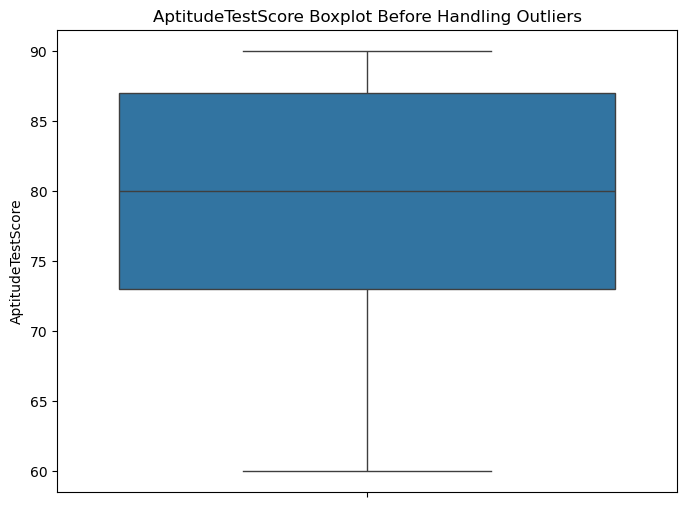

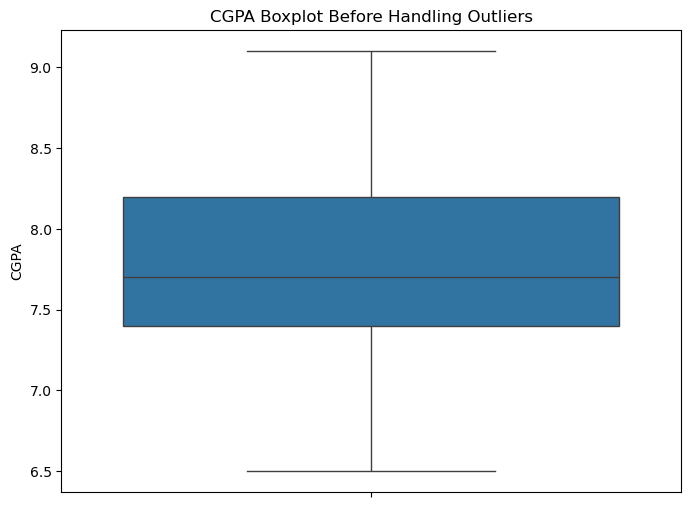

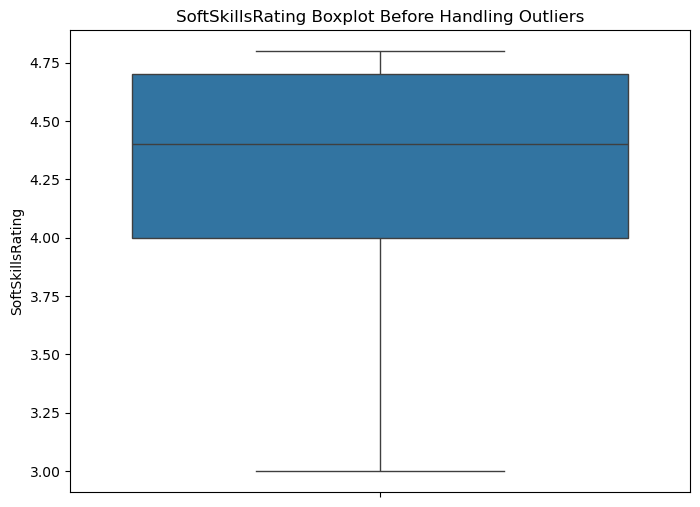

In [ ]:
# Boxplot for Age
plt.figure(figsize=(8, 6))
sns.boxplot(df['AptitudeTestScore'])
plt.title('AptitudeTestScore Boxplot Before Handling Outliers')
plt.show()

# Boxplot for CGPA
plt.figure(figsize=(8, 6))
sns.boxplot(df['CGPA'])
plt.title('CGPA Boxplot Before Handling Outliers')
plt.show()

# Boxplot for SoftSkillsRating
plt.figure(figsize=(8, 6))
sns.boxplot(df['SoftSkillsRating'])
plt.title('SoftSkillsRating Boxplot Before Handling Outliers')
plt.show()

### Conclusion :
The outliers in the data has been checked and we can observe that no outliers are present in the data.This cleaning process ensures more accurate model performance by eliminating extreme values that could skew results. The dataset is now ready for further analysis and modeling.

In [ ]:
df.corr(numeric_only=True)

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks,PlacementStatus
CGPA,1.000000,0.280601,0.435928,0.349686,0.461250,0.383547,0.404971,0.462313,0.423131
Internships,0.280601,1.000000,0.309196,0.279110,0.320725,0.273691,0.279837,0.317149,0.260340
Projects,0.435928,0.309196,1.000000,0.377865,0.540339,0.450294,0.499421,0.535708,0.475186
Workshops/Certifications,0.349686,0.279110,0.377865,1.000000,0.388061,0.342397,0.373045,0.418442,0.362268
AptitudeTestScore,0.461250,0.320725,0.540339,0.388061,1.000000,0.515400,0.513044,0.565105,0.521744
SoftSkillsRating,0.383547,0.273691,0.450294,0.342397,0.515400,1.000000,0.430734,0.466912,0.427284
SSC_Marks,0.404971,0.279837,0.499421,0.373045,0.513044,0.430734,1.000000,0.524916,0.469763
HSC_Marks,0.462313,0.317149,0.535708,0.418442,0.565105,0.466912,0.524916,1.000000,0.505746
PlacementStatus,0.423131,0.260340,0.475186,0.362268,0.521744,0.427284,0.469763,0.505746,1.000000


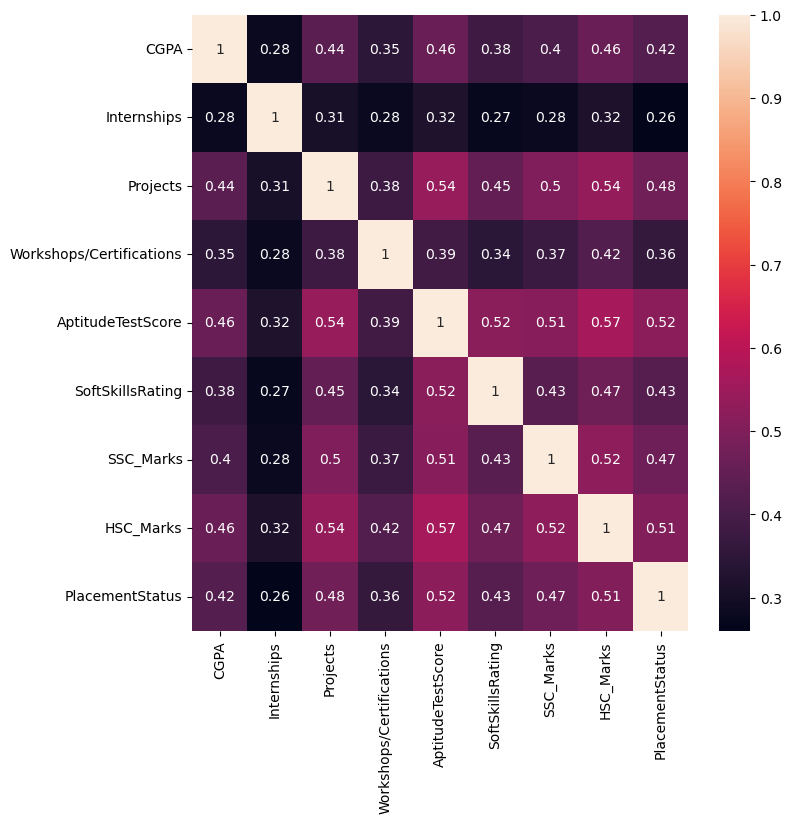

In [ ]:
#Showing correlation by using heatmap
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

### 3. Separation of features and target :

In [ ]:
#Separation of features and target :
feature=df.iloc[:,:-1]
target=df['PlacementStatus']

In [ ]:
feature

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,7.5,1,1,1,65,4.4,No,No,61,79
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82
2,7.3,1,2,2,82,4.8,Yes,No,79,80
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,Yes,No,85,66
9996,7.4,0,1,0,90,4.8,No,No,84,67
9997,8.4,1,3,0,70,4.8,Yes,Yes,79,81
9998,8.9,0,3,2,87,4.8,Yes,Yes,71,85


In [ ]:
target

0       0
1       1
2       0
3       1
4       1
       ..
9995    0
9996    1
9997    1
9998    1
9999    0
Name: PlacementStatus, Length: 10000, dtype: int64

### 4. Finding skewness

In [ ]:
#Descriptive statistics :
feature.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [ ]:
#Numerical Columns :
col=feature.select_dtypes(['int64','float64']).columns
col

Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks'],
      dtype='object')

CGPA
-0.4026524012746521


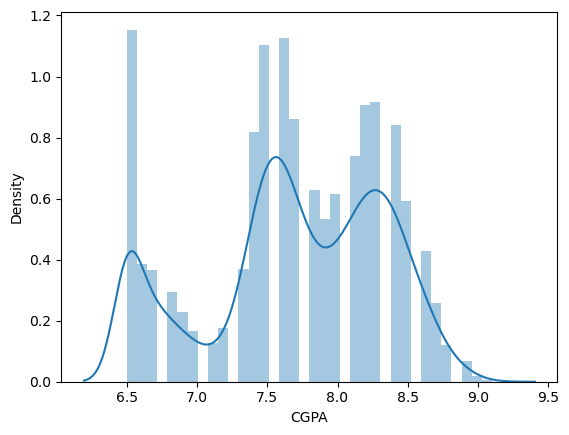

Internships
-0.055420473815338635


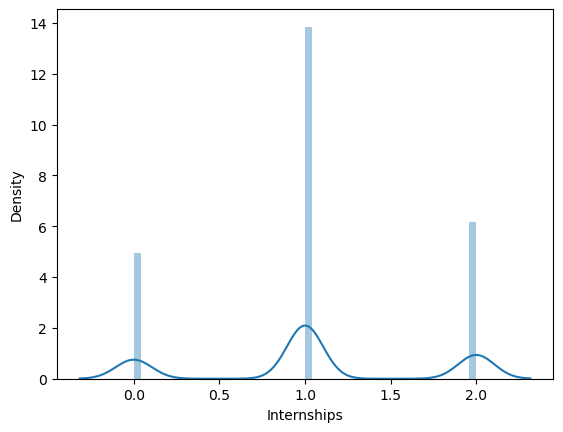

Projects
-0.07881844420863482


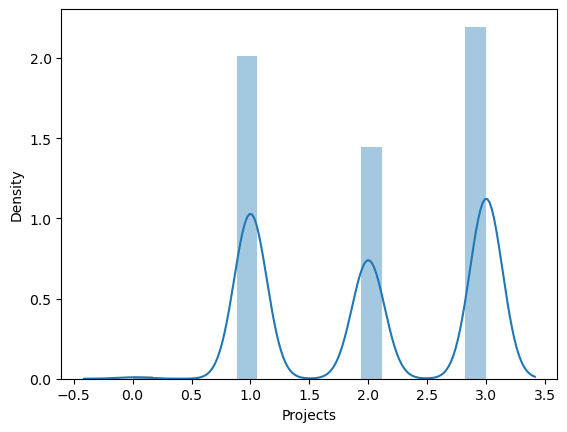

Workshops/Certifications
0.20453921303180922


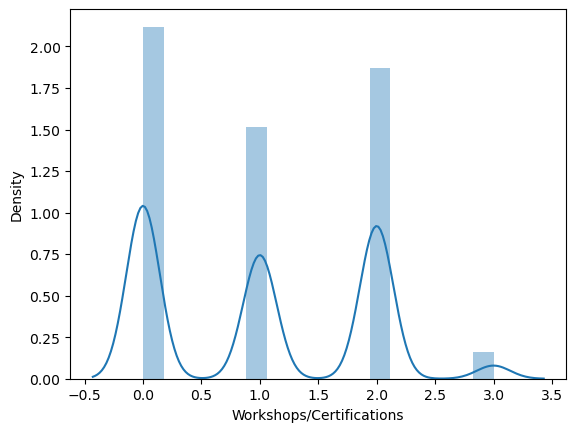

AptitudeTestScore
-0.3549574447765731


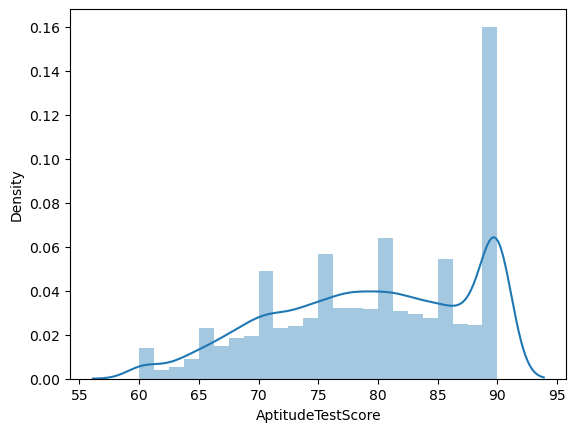

SoftSkillsRating
-0.676224087285456


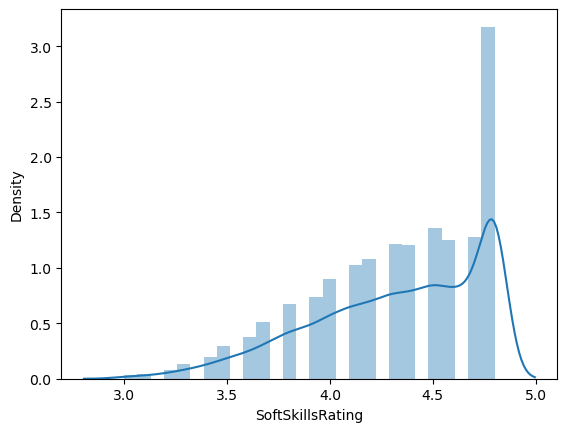

SSC_Marks
0.03437654576724137


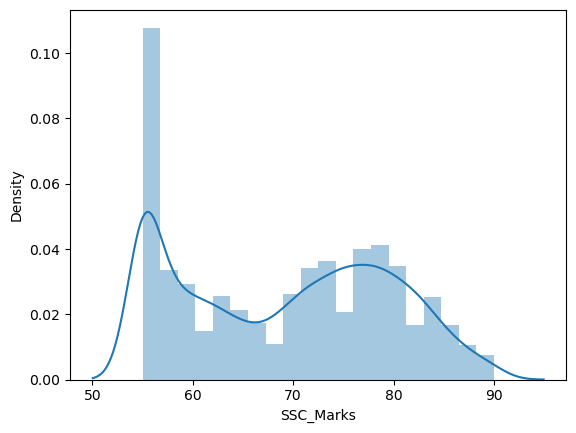

HSC_Marks
-0.0009851830109251342


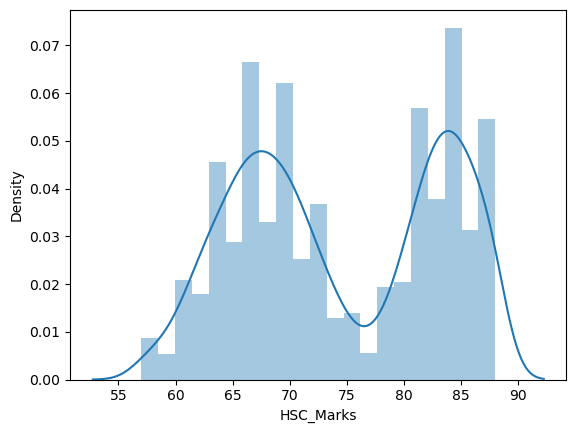

In [ ]:
# To know amount of skewness :
from scipy.stats import skew   #scipy :scientific python library

for i in feature[col]:
    print(i)
    print(skew(feature[i]))

    plt.figure()
    sns.distplot(feature[i])
    plt.show()

In [ ]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df['SoftSkillsRating'] = pt.fit_transform(df[['SoftSkillsRating']])
df['AptitudeTestScore'] = pt.fit_transform(df[['AptitudeTestScore']])

# Check new skewness
SoftskillRating_skewness = skew(df['SoftSkillsRating'])
print(f"New skewness after Yeo-Johnson transformation: {SoftskillRating_skewness:.4f}")

AptitudeTestScore_skewness = skew(df['AptitudeTestScore'])
print(f"New skewness after Yeo-Johnson transformation: {AptitudeTestScore_skewness:.4f}")

New skewness after Yeo-Johnson transformation: -0.1640
New skewness after Yeo-Johnson transformation: -0.1043


### 5. Encoding : Handling Categorical Data

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()

In [ ]:
cat_col=feature.select_dtypes(object).columns
cat_col

Index(['ExtracurricularActivities', 'PlacementTraining'], dtype='object')

In [ ]:
feature[cat_col]

,ExtracurricularActivities,PlacementTraining
0,No,No
1,Yes,Yes
2,Yes,No
3,Yes,Yes
4,Yes,Yes
...,...,...
9995,Yes,No
9996,No,No
9997,Yes,Yes
9998,Yes,Yes


In [ ]:
feature[cat_col]=oe.fit_transform(feature[cat_col])

In [ ]:
feature

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,7.5,1,1,1,65,4.4,0.0,0.0,61,79
1,8.9,0,3,2,90,4.0,1.0,1.0,78,82
2,7.3,1,2,2,82,4.8,1.0,0.0,79,80
3,7.5,1,1,2,85,4.4,1.0,1.0,81,80
4,8.3,1,2,2,86,4.5,1.0,1.0,74,88
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1.0,0.0,85,66
9996,7.4,0,1,0,90,4.8,0.0,0.0,84,67
9997,8.4,1,3,0,70,4.8,1.0,1.0,79,81
9998,8.9,0,3,2,87,4.8,1.0,1.0,71,85


### 6. Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
feature.iloc[:,:]=sc.fit_transform(feature.iloc[:,:])

In [ ]:
x=feature
y=target

In [ ]:
x

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,-0.309343,-0.073889,-1.182822,-0.014598,-1.770910,0.184742,-1.188261,-1.651836,-0.782306,0.504368
1,1.877818,-1.575689,1.121526,1.091319,1.292970,-0.787072,0.841566,0.605387,0.847618,0.840726
2,-0.621794,-0.073889,-0.030648,1.091319,0.312528,1.156555,0.841566,-1.651836,0.943496,0.616487
3,-0.309343,-0.073889,-1.182822,1.091319,0.680194,0.184742,0.841566,0.605387,1.135251,0.616487
4,0.940464,-0.073889,-0.030648,1.091319,0.802749,0.427695,0.841566,0.605387,0.464106,1.513441
...,...,...,...,...,...,...,...,...,...,...
9995,-0.309343,-0.073889,-1.182822,1.091319,-0.913024,-1.030025,0.841566,-1.651836,1.518763,-0.953181
9996,-0.465568,-1.575689,-1.182822,-1.120516,1.292970,1.156555,-1.188261,-1.651836,1.422885,-0.841062
9997,1.096689,-0.073889,1.121526,-1.120516,-1.158134,1.156555,0.841566,0.605387,0.943496,0.728606
9998,1.877818,-1.575689,1.121526,1.091319,0.925304,1.156555,0.841566,0.605387,0.176473,1.177083


In [ ]:
y

0       0
1       1
2       0
3       1
4       1
       ..
9995    0
9996    1
9997    1
9998    1
9999    0
Name: PlacementStatus, Length: 10000, dtype: int64

### 7. Splitting into Training and Testing :

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and test sets
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=85)

# Check the shape of training and test sets
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((8000, 10), (2000, 10), (8000,), (2000,))

## Classification Algorithms :

## 1. KNN(K-Nearest Neighbour) Algorithm

### Train the Model :

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the kNN model
k = 5  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(xtrain, ytrain)

KNeighborsClassifier()

### Make Predictions and Evaluate

In [ ]:
#a. Predictions

# Predict on the test set
ypred = knn.predict(xtest)

In [ ]:
#To evaluate a model
from sklearn.metrics import accuracy_score          #this metrics used to check accuracy

In [ ]:
accuracy_score(ypred,ytest)

0.7795

In [ ]:
#This class helps to identify best parameters of respective algorithm which affect accuracy score.
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={'n_neighbors':[3,5,7,9,11],'metric':['euclidean','manhattan','hamming','minkowski']}

In [ ]:
gs=GridSearchCV(knn,param_grid,cv=3)
gs.fit(xtrain,ytrain)
ypred=gs.predict(xtest)

In [ ]:
gs.best_params_

{'metric': 'manhattan', 'n_neighbors': 11}

In [ ]:
accuracy_score(ytest,ypred)

0.7795

### Hypertuning of k
To find best value of k

In [ ]:
acc_list=[]
for i in range(1,31):
    kn1=KNeighborsClassifier(n_neighbors=i)
    kn1.fit(xtrain,ytrain)
    ypred=kn1.predict(xtest)

    ac=accuracy_score(ytest,ypred)
    acc_list.append(ac)

In [ ]:
acc_list

[0.7285,
 0.7475,
 0.7585,
 0.768,
 0.7795,
 0.776,
 0.7835,
 0.7835,
 0.7815,
 0.781,
 0.7785,
 0.7805,
 0.7825,
 0.7865,
 0.784,
 0.7845,
 0.7855,
 0.7885,
 0.7855,
 0.789,
 0.786,
 0.7845,
 0.786,
 0.786,
 0.785,
 0.789,
 0.7875,
 0.7845,
 0.7855,
 0.785]

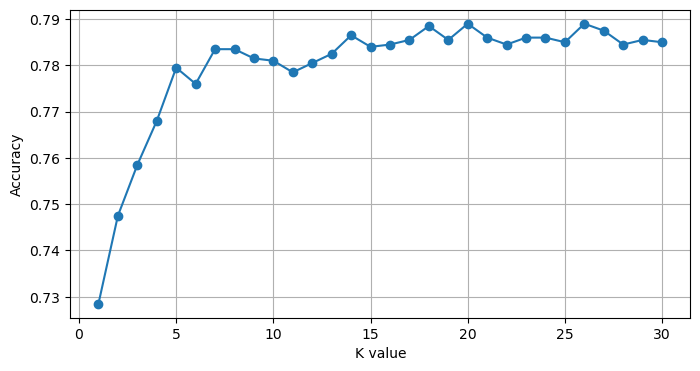

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(range(1,31),acc_list,marker='o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Initialize the kNN model
k = 20  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(xtrain, ytrain)

KNeighborsClassifier(n_neighbors=20)

In [ ]:
# Predict on the test set
ypred = knn.predict(xtest)

In [ ]:
#To evaluate a model
from sklearn.metrics import accuracy_score         #this metrics used to check accuracy
accuracy_score(ytest,ypred)

0.789

### Conclusion:
The K-Nearest Neighbors (KNN) algorithm was used to classify the dataset, achieving an initial accuracy of 77.95%.
To enhance the model's performance, hyperparameter tuning was conducted using GridSearchCV.
By selecting the optimal parameters (gs.best_params_), the accuracy improved to 78.9%.
This demonstrates the importance of fine-tuning hyperparameters to achieve better classification results.

## 2. Logistic Regression :

In [ ]:
#Building model
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

In [ ]:
#Evaluate a model
from sklearn.metrics import classification_report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
#Building model
#from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(solver='liblinear')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
lr=LogisticRegression(solver='newton-cg')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
lr=LogisticRegression(solver='sag')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
lr=LogisticRegression(solver='saga')
lr.fit(xtrain,ytrain)
ypred=lr.predict(xtest)

print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



### Conclusion :
The logistic regression model achieved a consistent accuracy of 80% across different solvers (default, liblinear,newton-cg,
sag, and saga), indicating stable performance and robustness.
    This suggests that the data is relatively simple, and the solver choice has minimal impact on accuracy.

## 3. Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
svc=SVC()

def mymodel(m):
    m.fit(xtrain,ytrain)
    ypred=m.predict(xtest)
    print(classification_report(ytest,ypred))
    return m

In [ ]:
mymodel(svc)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1168
           1       0.77      0.73      0.75       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



SVC()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
p1=Pipeline(steps=[('scaling',StandardScaler()),('svm',SVC()),])

In [ ]:
p1.fit(xtrain,ytrain)
ypred=p1.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1168
           1       0.77      0.73      0.75       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



### Hypertuning with kernel,c,gamma :

In [ ]:
svc=SVC(kernel='linear')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1168
           1       0.76      0.76      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



SVC(kernel='linear')

In [ ]:
svc=SVC(kernel='sigmoid')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1168
           1       0.66      0.64      0.65       832

    accuracy                           0.71      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.71      0.71      0.71      2000



SVC(kernel='sigmoid')

In [ ]:
svc=SVC(kernel='poly')
mymodel(svc)

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1168
           1       0.75      0.76      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



SVC(kernel='poly')

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={'C':[1,10],'gamma':[1,10],'kernel':['rbf']}

In [ ]:
gd=GridSearchCV(svc,param_grid,verbose=3)
#Verbose is not a hyperparameter.It is used just to display info
gd.fit(xtrain,ytrain)
ypred=gd.predict(xtest)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.780 total time=   5.6s
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.773 total time=   5.7s
[CV 3/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.767 total time=   5.6s
[CV 4/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.792 total time=   5.7s
[CV 5/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.786 total time=   5.8s
[CV 1/5] END .........C=1, gamma=10, kernel=rbf;, score=0.694 total time=   7.4s
[CV 2/5] END .........C=1, gamma=10, kernel=rbf;, score=0.699 total time=   7.4s
[CV 3/5] END .........C=1, gamma=10, kernel=rbf;, score=0.693 total time=   7.4s
[CV 4/5] END .........C=1, gamma=10, kernel=rbf;, score=0.697 total time=   7.4s
[CV 5/5] END .........C=1, gamma=10, kernel=rbf;, score=0.700 total time=   7.4s
[CV 1/5] END .........C=10, gamma=1, kernel=rbf;, score=0.748 total time=   7.8s
[CV 2/5] END .........C=10, gamma=1, kernel=rbf;,

In [ ]:
gd.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
svc=gd.best_estimator_
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82      1168
           1       0.78      0.66      0.71       832

    accuracy                           0.78      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.78      0.78      0.78      2000



### Conclusion:
The Support Vector Machine achieve 80% accuracy. Again here done hypertune with kernel(linear,poly) for search better accuaacy but accuracy remains same.

## 4. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [ ]:
mymodel(dt)

              precision    recall  f1-score   support

           0       0.75      0.76      0.76      1168
           1       0.66      0.65      0.65       832

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



DecisionTreeClassifier()

In [ ]:
#To check accuracy during training
dt.score(xtrain,ytrain)              #overfitting problem

0.99925

### Hypertuning in DT (Pruning techniques)

In [ ]:
for i in range(1,31):
    dt1=DecisionTreeClassifier(max_depth=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"Max Depth={i} Accuracy={ac}")

Max Depth=1 Accuracy=0.7565
Max Depth=2 Accuracy=0.7565
Max Depth=3 Accuracy=0.784
Max Depth=4 Accuracy=0.7865
Max Depth=5 Accuracy=0.781
Max Depth=6 Accuracy=0.7735
Max Depth=7 Accuracy=0.7795
Max Depth=8 Accuracy=0.777
Max Depth=9 Accuracy=0.7625
Max Depth=10 Accuracy=0.7615
Max Depth=11 Accuracy=0.7565
Max Depth=12 Accuracy=0.7495
Max Depth=13 Accuracy=0.737
Max Depth=14 Accuracy=0.7225
Max Depth=15 Accuracy=0.7225
Max Depth=16 Accuracy=0.7275
Max Depth=17 Accuracy=0.721
Max Depth=18 Accuracy=0.7235
Max Depth=19 Accuracy=0.7135
Max Depth=20 Accuracy=0.7195
Max Depth=21 Accuracy=0.709
Max Depth=22 Accuracy=0.7085
Max Depth=23 Accuracy=0.7125
Max Depth=24 Accuracy=0.7145
Max Depth=25 Accuracy=0.7065
Max Depth=26 Accuracy=0.714
Max Depth=27 Accuracy=0.719
Max Depth=28 Accuracy=0.714
Max Depth=29 Accuracy=0.715
Max Depth=30 Accuracy=0.7145


In [ ]:
dt2=DecisionTreeClassifier(max_depth=7)
mymodel(dt2)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1168
           1       0.74      0.73      0.73       832

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



DecisionTreeClassifier(max_depth=7)

In [ ]:
dt2.score(xtrain,ytrain)

0.816

In [ ]:
#Hypertuning with mean_samples_split
for i in range(2,51):
    dt1=DecisionTreeClassifier(min_samples_split=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"min samples split={i} Accuracy={ac}")

min samples split=2 Accuracy=0.723
min samples split=3 Accuracy=0.7205
min samples split=4 Accuracy=0.718
min samples split=5 Accuracy=0.7225
min samples split=6 Accuracy=0.7175
min samples split=7 Accuracy=0.7275
min samples split=8 Accuracy=0.729
min samples split=9 Accuracy=0.7305
min samples split=10 Accuracy=0.7265
min samples split=11 Accuracy=0.73
min samples split=12 Accuracy=0.7305
min samples split=13 Accuracy=0.7315
min samples split=14 Accuracy=0.735
min samples split=15 Accuracy=0.7405
min samples split=16 Accuracy=0.741
min samples split=17 Accuracy=0.7425
min samples split=18 Accuracy=0.746
min samples split=19 Accuracy=0.7485
min samples split=20 Accuracy=0.7485
min samples split=21 Accuracy=0.748
min samples split=22 Accuracy=0.7535
min samples split=23 Accuracy=0.7545
min samples split=24 Accuracy=0.756
min samples split=25 Accuracy=0.756
min samples split=26 Accuracy=0.756
min samples split=27 Accuracy=0.7575
min samples split=28 Accuracy=0.758
min samples split=29 A

In [ ]:
dt3=DecisionTreeClassifier(min_samples_split=49)
mymodel(dt3)

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1168
           1       0.73      0.71      0.72       832

    accuracy                           0.77      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000



DecisionTreeClassifier(min_samples_split=49)

In [ ]:
dt3.score(xtrain,ytrain)

0.830375

In [ ]:
for i in range(1,51):
    dt1=DecisionTreeClassifier(min_samples_leaf=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    print(f"min samples split={i} Accuracy={ac}")

min samples split=1 Accuracy=0.7155
min samples split=2 Accuracy=0.722
min samples split=3 Accuracy=0.732
min samples split=4 Accuracy=0.7425
min samples split=5 Accuracy=0.748
min samples split=6 Accuracy=0.752
min samples split=7 Accuracy=0.7585
min samples split=8 Accuracy=0.7615
min samples split=9 Accuracy=0.762
min samples split=10 Accuracy=0.765
min samples split=11 Accuracy=0.7635
min samples split=12 Accuracy=0.7585
min samples split=13 Accuracy=0.762
min samples split=14 Accuracy=0.7705
min samples split=15 Accuracy=0.7765
min samples split=16 Accuracy=0.777
min samples split=17 Accuracy=0.783
min samples split=18 Accuracy=0.784
min samples split=19 Accuracy=0.7845
min samples split=20 Accuracy=0.784
min samples split=21 Accuracy=0.785
min samples split=22 Accuracy=0.7885
min samples split=23 Accuracy=0.7885
min samples split=24 Accuracy=0.791
min samples split=25 Accuracy=0.7905
min samples split=26 Accuracy=0.7895
min samples split=27 Accuracy=0.7855
min samples split=28 Ac

In [ ]:
dt4=DecisionTreeClassifier(min_samples_leaf=19)
mymodel(dt4)

              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1168
           1       0.75      0.72      0.74       832

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



DecisionTreeClassifier(min_samples_leaf=19)

In [ ]:
dt4.score(xtrain,ytrain)

0.82

### Conclusion :
The Decision Tree model initially achieved an accuracy of 71% without hyperparameter tuning. After applying hyperparameter tuning, various parameters were adjusted to optimize the model performance:

max_depth resulted in an accuracy of 78%,

min_samples_split improved the accuracy to 77%, and

min_samples_leaf yielded an accuracy of 78%.
    
These improvements indicate that hyperparameter tuning significantly enhanced the model's performance, with min_samples_split providing the best results. Therefore, tuning these parameters helps improve the model's ability to generalize and achieve better predictive accuracy.

## 5. Ensemble Learning

### 1.1)Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
bg=BaggingClassifier(LogisticRegression())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1168
           1       0.76      0.75      0.76       832

    accuracy                           0.80      2000
   macro avg       0.80      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
bg=BaggingClassifier(KNeighborsClassifier())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1168
           1       0.74      0.69      0.71       832

    accuracy                           0.77      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000



In [ ]:
bg=BaggingClassifier(SVC())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1168
           1       0.77      0.72      0.75       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
bg=BaggingClassifier(DecisionTreeClassifier())
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82      1168
           1       0.78      0.65      0.71       832

    accuracy                           0.78      2000
   macro avg       0.78      0.76      0.76      2000
weighted avg       0.78      0.78      0.77      2000



### Random Forest :

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier()
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1168
           1       0.77      0.69      0.73       832

    accuracy                           0.79      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.78      0.79      0.78      2000



### Conclusion :
By applying Bagging from Ensemble Learning, the **Logistic Regression Classifier & Support Vector Classifier(SVC)** outperforms other models with the best accuracy of **80%**. This result highlights the effectiveness of ensemble methods in improving model performance. Bagging helps in reducing variance and overfitting, and in this case, the Logistic Regression Classifier benefits from this technique, delivering a more robust and reliable prediction compared to other classifiers tested.

### 1.2) Voting

In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
models=[]
acc=[]
models.append(("LogisticReg",LogisticRegression()))
models.append(("Dec Tree",DecisionTreeClassifier()))
models.append(("knn",KNeighborsClassifier()))
models.append(("svm",SVC()))

In [ ]:
vc=VotingClassifier(estimators=models)
vc.fit(xtrain,ytrain)
ypred=vc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1168
           1       0.78      0.69      0.73       832

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



### Conclusion :
The Voting Classifier combines multiple models (Logistic Regression, Decision Tree, K-Nearest Neighbors, and SVM) and achieves 79% accuracy.

### 2) Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada=AdaBoostClassifier()
ada.fit(xtrain,ytrain)
ypred=ada.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1168
           1       0.77      0.73      0.75       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.80      0.79      2000



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gd=GradientBoostingClassifier()
gd.fit(xtrain,ytrain)
ypred=gd.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1168
           1       0.77      0.73      0.75       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.80      0.79      2000



In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb=XGBClassifier()
xgb.fit(xtrain,ytrain)
ypred=xgb.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1168
           1       0.74      0.71      0.73       832

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



### Conclusion :

- **AdaBoost** achieved an accuracy of **80%**, showing strong performance with better precision and recall for class 1.
- **Gradient Boosting** also gave an accuracy of **80%**, performing similarly to AdaBoost with balanced precision and recall.
- **XGBoost** achieved an accuracy of **78%**, slightly lower than the other two but still a competitive result.

In summary, **AdaBoost & Gradient Boosting** provides the best performance among the boosting algorithms tested.

## 6. Naive Bay's

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import classification_report

In [ ]:
mymodel(GaussianNB())

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1168
           1       0.75      0.77      0.76       832

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000



GaussianNB()

In [ ]:
mymodel(BernoulliNB())

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1168
           1       0.75      0.76      0.75       832

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



BernoulliNB()

##### **Conclusion**:
The Naïve Bayes classifier for the student placement analysis project, specifically implementing GaussianNB and BernoulliNB.Among them, GaussianNB achieved the highest accuracy of **80**%.

# Conclusion:
The Student Placement Analysis project aimed to predict placement outcomes using various classification algorithms, leveraging a dataset that encompasses academic performance, practical experience, skill development, and extracurricular involvement. Through extensive experimentation with different machine learning models, the highest accuracy of 80% was achieved using **Logistic Regression, Support Vector Machine (SVM), Ensemble Learning (Bagging and Boosting), and Naïve Bayes**.

These models effectively captured the relationships between features such as CGPA, internships, projects, certifications, and soft skills, which play a crucial role in determining a student’s employability. The success of these algorithms highlights the significance of both structured learning (academic scores) and practical exposure (internships and projects) in influencing placement outcomes. The findings from this study can serve as a valuable resource for students, educators, and institutions, enabling them to identify key areas of improvement and enhance placement preparedness. Furthermore, the project demonstrates how machine learning can be leveraged to make data-driven decisions, optimize career counseling, and improve student employability strategies in educational institutions. Future work can explore feature engineering, deep learning models, or external datasets to further enhance prediction accuracy.

#### End User
The end users of this project include students, educational institutions, career counselors, and recruiters.

**Students** can use the insights to understand key factors influencing placements and focus on improving areas like academics, internships, and soft skills.

**Educational Institutions** can leverage the findings to enhance curriculum design, placement training programs, and career guidance initiatives.

**Career Counselors** can utilize the model’s predictions to provide personalized advice to students, helping them strengthen their employability.

**Recruiters** can use the analysis to identify candidates who meet industry requirements, streamlining the hiring process.
Overall, this project helps bridge the gap between academic learning and industry expectations, improving student placement outcomes.